### IE 7275 Data Mining- Final Project 

### IPL cricket score prediction

#### Team Members:  
A team of aspiring data scientists...

##### -> Jaamie Maarsh Joy Martin
##### -> Kalyan Kumar Chenchu Malakondaiah

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler



#### We have chosen an IPL dataset containing records from 2008-2017

In [2]:
ipl_df = pd.read_csv('/Users/jaamiemaarshj/Desktop/  DAE Course Materials/Data Mining/IPL auctions/Milestone 2/ipl_dataset_2008_2017.csv')
display(ipl_df.head())


,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [3]:
ipl_df.shape

(76014, 15)

In [4]:
ipl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


#### Descriptive statistics

In [5]:
ipl_df.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


#### Data Preprocessing

In [6]:
# Checking the unique values for every columns in the dataset
ipl_df.nunique()

mid               617
date              442
venue              35
bat_team           14
bowl_team          14
batsman           411
bowler            329
runs              252
wickets            11
overs             140
runs_last_5       102
wickets_last_5      8
striker           155
non-striker        88
total             138
dtype: int64

In [7]:
# Checking for null values
NAN_values = ipl_df.isnull().sum()
print (NAN_values)

# Total number of null values in the dataset
total_NAN = NAN_values.sum()
print("\nTherefore, The total No.of Null Values in the Dataset:", total_NAN)


mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64

Therefore, The total No.of Null Values in the Dataset: 0


In [8]:
# taking a backup of the data for initial visualisation

ipl_visual = ipl_df.copy()

In [9]:
#Dropping of the unccessary columns
print(f'Before Removing the Unnecessary Columns : {ipl_df.shape}')
#The reason for dropping the below columns is that we feel that the below columns doesnt contribute much in the model creation
ipl_df.drop(columns=['date', 'mid', 'runs_last_5', 'wickets_last_5', 'batsman', 'bowler', 'striker', 'non-striker'], inplace=True)

print(f'After Removing the Unnecessary Columns : {ipl_df.shape}')
display(ipl_df.head())

Before Removing the Unnecessary Columns : (76014, 15)
After Removing the Unnecessary Columns : (76014, 7)


,venue,bat_team,bowl_team,runs,wickets,overs,total
0,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.1,222
1,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.2,222
2,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.2,222
3,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.3,222
4,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.4,222


In [10]:
ipl_df = ipl_df.rename(columns={'bat_team': 'Team_Batting_First', 'bowl_team': 'Team_Bowling_First', 'total': 'Innings_total'})
# Print the DataFrame to verify the changes
display(ipl_df.head())



,venue,Team_Batting_First,Team_Bowling_First,runs,wickets,overs,Innings_total
0,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.1,222
1,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.2,222
2,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.2,222
3,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.3,222
4,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.4,222


In [11]:
# Define Consistent Teams 
consistant_teams_across_years = ['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
              'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
              'Delhi Daredevils', 'Sunrisers Hyderabad']
     

The team who have been playing the most number of seasons having the same name so as to eliminate potential outliers

In [12]:
unique_values = ipl_df['Team_Batting_First'].unique()

print(unique_values)

['Kolkata Knight Riders' 'Chennai Super Kings' 'Rajasthan Royals'
 'Mumbai Indians' 'Deccan Chargers' 'Kings XI Punjab'
 'Royal Challengers Bangalore' 'Delhi Daredevils' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Gujarat Lions' 'Rising Pune Supergiant']


In [13]:
# Removing the Inconsistancies/outliers
print(f'Before Removing Inconsistent Teams : {ipl_df.shape}')
ipl_df = ipl_df[(ipl_df['Team_Batting_First'].isin(consistant_teams_across_years)) & (ipl_df['Team_Bowling_First'].isin(consistant_teams_across_years))]
print(f'After Removing Irrelevant Columns : {ipl_df.shape}')
print(f"Consistent Teams : \n{ipl_df['Team_Batting_First'].unique()}")
display(ipl_df.head(5))


Before Removing Inconsistent Teams : (76014, 7)
After Removing Irrelevant Columns : (53811, 7)
Consistent Teams : 
['Kolkata Knight Riders' 'Chennai Super Kings' 'Rajasthan Royals'
 'Mumbai Indians' 'Kings XI Punjab' 'Royal Challengers Bangalore'
 'Delhi Daredevils' 'Sunrisers Hyderabad']


,venue,Team_Batting_First,Team_Bowling_First,runs,wickets,overs,Innings_total
0,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.1,222
1,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.2,222
2,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.2,222
3,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.3,222
4,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.4,222


In [14]:

# Get unique values for the specified column
unique_IPL_Venues = ipl_df['venue'].unique()
unique_IPL_Teams = ipl_df['Team_Batting_First'].unique()

# Print the unique values
print("Unique values for 'venue':", unique_IPL_Venues)
print("Unique values for 'Team':", unique_IPL_Teams)

Unique values for 'venue': ['M Chinnaswamy Stadium' 'Punjab Cricket Association Stadium, Mohali'
 'Feroz Shah Kotla' 'Wankhede Stadium' 'Sawai Mansingh Stadium'
 'MA Chidambaram Stadium, Chepauk' 'Eden Gardens'
 'Dr DY Patil Sports Academy' 'Newlands' "St George's Park" 'Kingsmead'
 'SuperSport Park' 'Buffalo Park' 'New Wanderers Stadium'
 'De Beers Diamond Oval' 'OUTsurance Oval' 'Brabourne Stadium'
 'Sardar Patel Stadium, Motera'
 'Himachal Pradesh Cricket Association Stadium'
 'Subrata Roy Sahara Stadium' 'Rajiv Gandhi International Stadium, Uppal'
 'Shaheed Veer Narayan Singh International Stadium'
 'JSCA International Stadium Complex' 'Sheikh Zayed Stadium'
 'Sharjah Cricket Stadium' 'Dubai International Cricket Stadium'
 'Barabati Stadium' 'Maharashtra Cricket Association Stadium'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
 'Punjab Cricket Association IS Bindra Stadium, Mohali'
 'Holkar Cricket Stadium']
Unique values for 'Team': ['Kolkata Knight Riders' 'Chennai Supe

In [15]:
ipl_df.shape

(53811, 7)

It can be verified that the above venues and teams are legit and does not contain any wrong/misleading data.

PS: Some years between 2008-2017, IPL was played in UAE and South Africa

/var/folders/0c/6l7fjjk134q20fw6s25nlr4h0000gn/T/ipykernel_9480/1050473890.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  heatmap(data=ipl_df.corr(), annot=True)


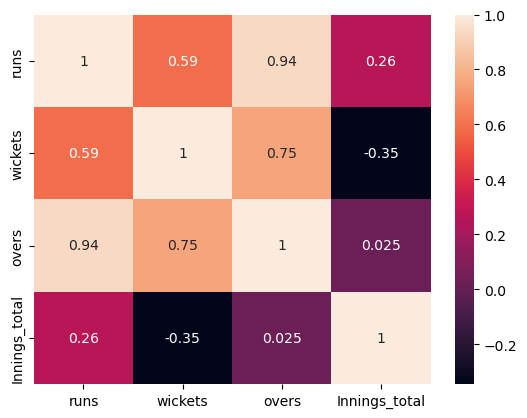

In [16]:
## Checking the relation between the numerical variables before feature engineering
from seaborn import heatmap
heatmap(data=ipl_df.corr(), annot=True)

ipl_df_teams = ipl_df.copy()
     

### Data Visualisations

#### 1. Correlation matrix - Which points out the correlation between the variables, wherein the target variable would be 'Runs'

/var/folders/0c/6l7fjjk134q20fw6s25nlr4h0000gn/T/ipykernel_9480/2778915339.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = ipl_visual.corr()


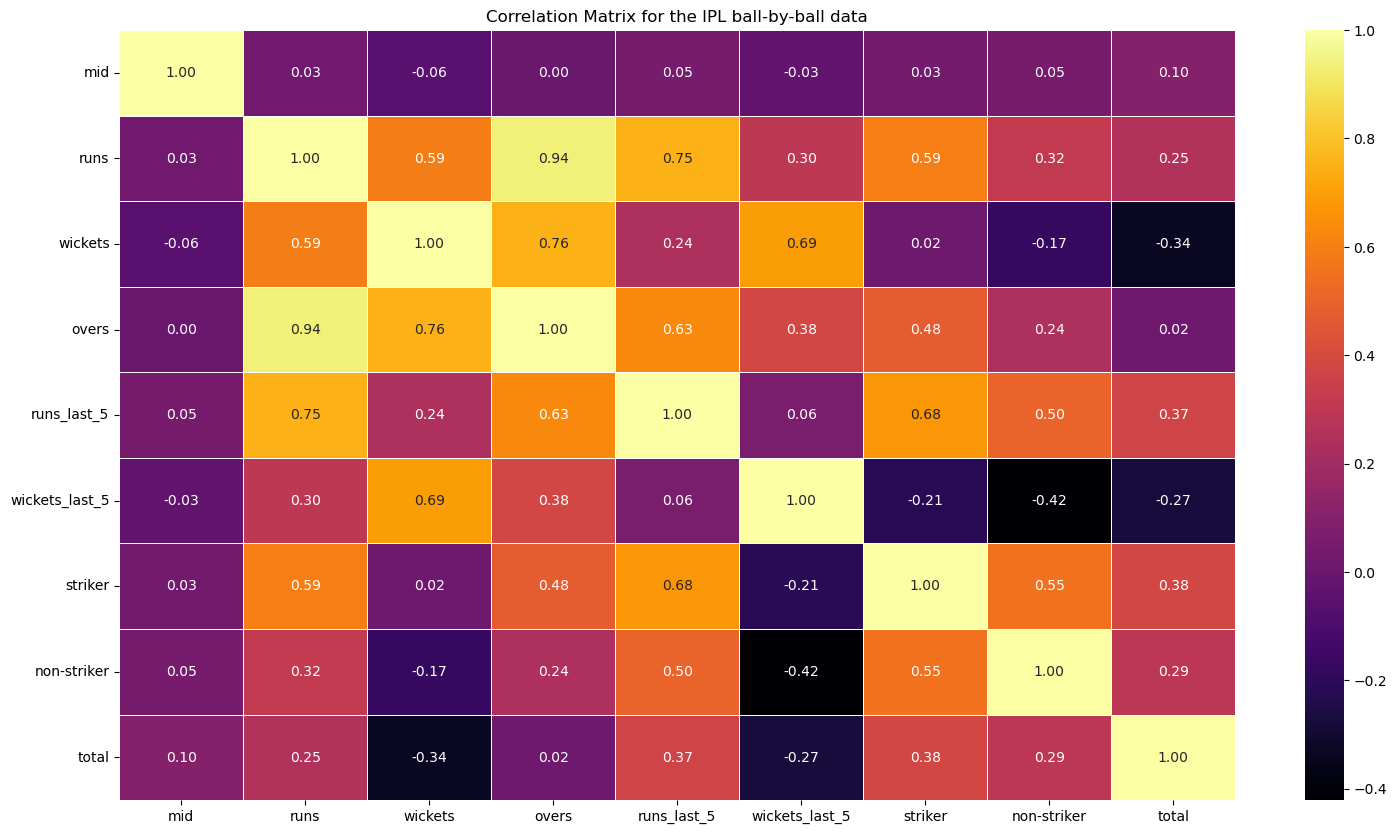

In [17]:
#Plotting the correlation matrix 
correlation_matrix = ipl_visual.corr()

plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='inferno', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix for the IPL ball-by-ball data')
plt.show()



#### Feature Selection
From the above matrix it can be found that the attributes, 'Overs', 'Wickets', 'runs_last_5' have a detremental impact on the runs, which is the target variable.

#### 2. Checking for Data imbalance

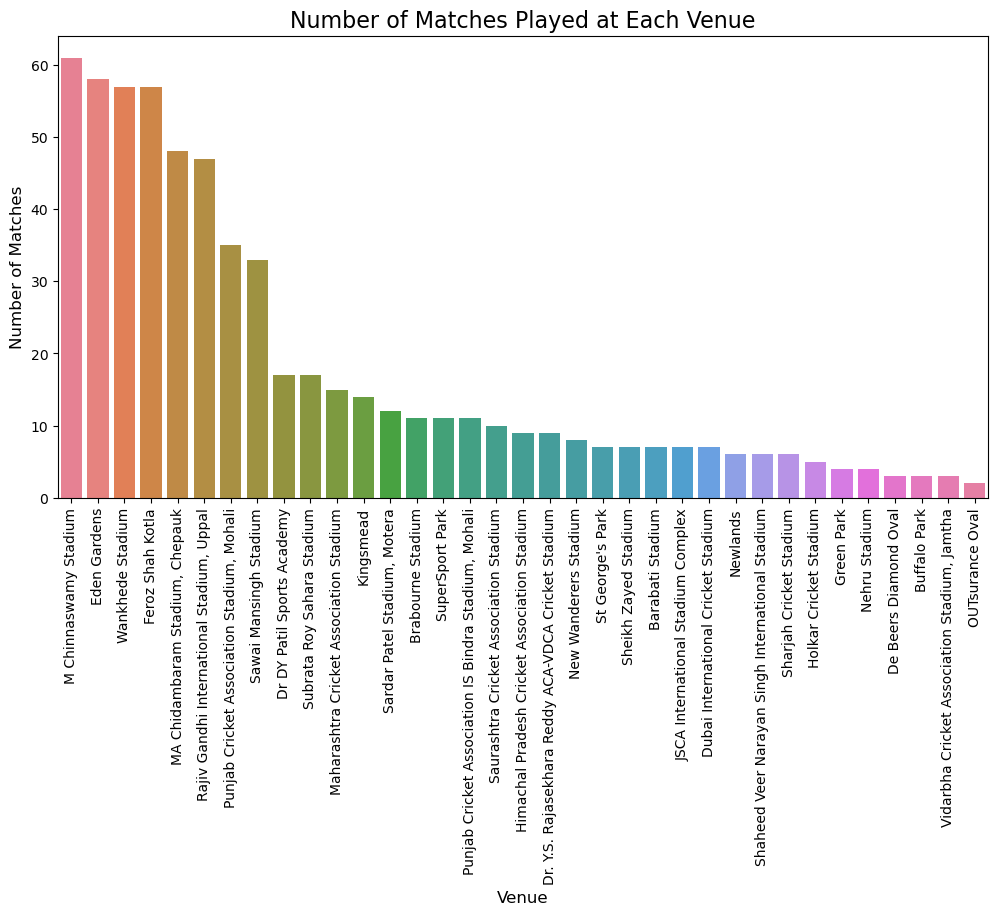

In [18]:
# Group the data by 'venue' and count the number of matches
venue_counts = ipl_visual.groupby('venue')['mid'].nunique().reset_index()

# Rename the columns
venue_counts.columns = ['venue', 'num_matches']

# Sort the values in descending order
venue_counts = venue_counts.sort_values('num_matches', ascending=False)

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='venue', y='num_matches', data=venue_counts, palette='husl')
plt.xlabel('Venue', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.title('Number of Matches Played at Each Venue', fontsize=16)
plt.xticks(rotation=90)
plt.show()

From the above chart it can be found that the M.Chinnasamy Stadium in Bengaluru has produced more number of matches in that period, which are closely followed by Eden gardens and Wankhede stadium in Kolkata and Mumbai.

#### 3. Checking for Outliers in both the batting and bowling departments

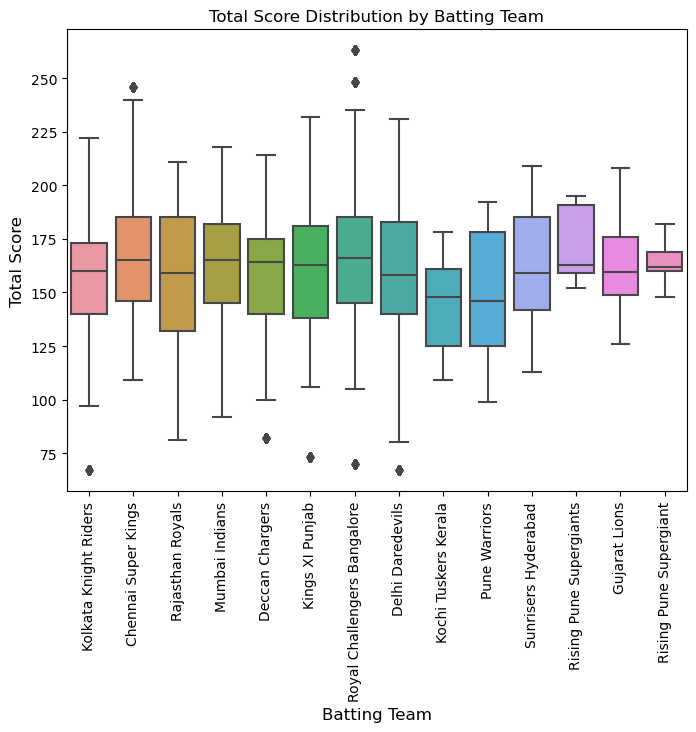

In [19]:
# Plotting a box plot to determine the mean scores scored by each team
plt.figure(figsize=(8, 6))

# Create a boxplot
sns.boxplot(x='bat_team', y='total', data=ipl_visual)

# Add title and axis labels
plt.title('Total Score Distribution by Batting Team', fontsize=12)
plt.xlabel('Batting Team', fontsize=12)
plt.ylabel('Total Score', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Show the plot
plt.show()

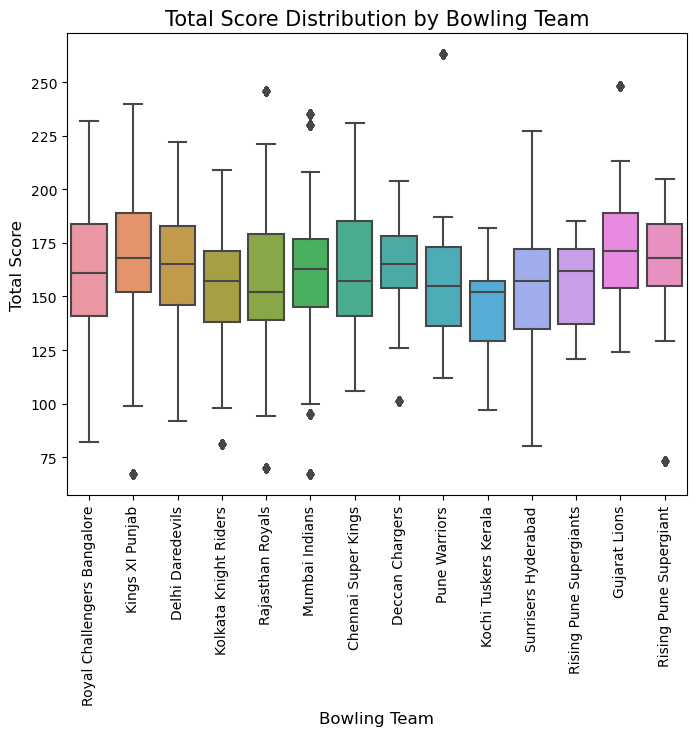

In [20]:
plt.figure(figsize=(8, 6))

# Create a boxplot
sns.boxplot(x='bowl_team', y='total', data=ipl_visual)

# Add title and axis labels
plt.title('Total Score Distribution by Bowling Team', fontsize=15)
plt.xlabel('Bowling Team', fontsize=12)
plt.ylabel('Total Score', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Show the plot
plt.show()

In this scenario, eventhough the presence of extreme maximum and minimum scores, the outliers, they are not being removed as it might hamper the quality of data and lead to loss in accuracy with regards to the venues the teams play.

#### 4. Eshtablishing the relation between the scores

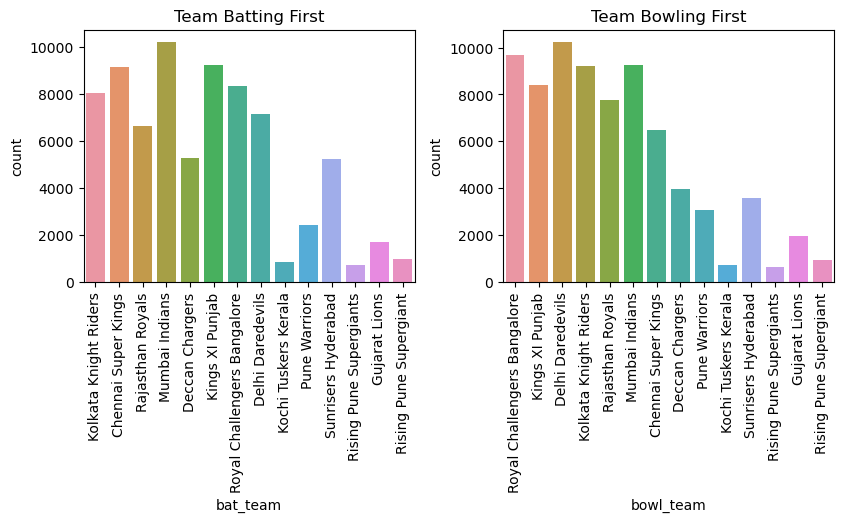

In [21]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 2)
sns.countplot(x='bat_team', data=ipl_visual)
plt.title('Team Batting First')
plt.xticks(rotation=90)

plt.subplot(2, 3, 3)
sns.countplot(x='bowl_team', data=ipl_visual)
plt.title('Team Bowling First')
plt.xticks(rotation=90)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

From the batting point of view, the Mumbai Indians are the team which has score the maximum amount of runs batting first with this they have also won 5 titles in this period.

The Sunrisers Hyderabad have the best team bowling during this period as they have given away very less runs in this period.

#### 5. Relationship of impact

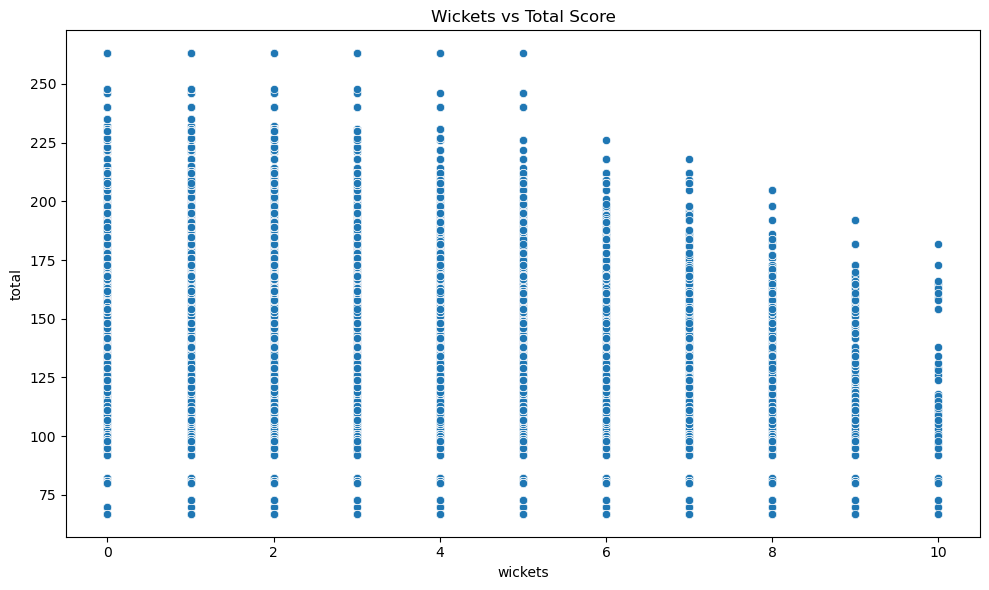

In [22]:
plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(x=ipl_visual['wickets'], y=ipl_visual['total'])
plt.title('Wickets vs Total Score')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

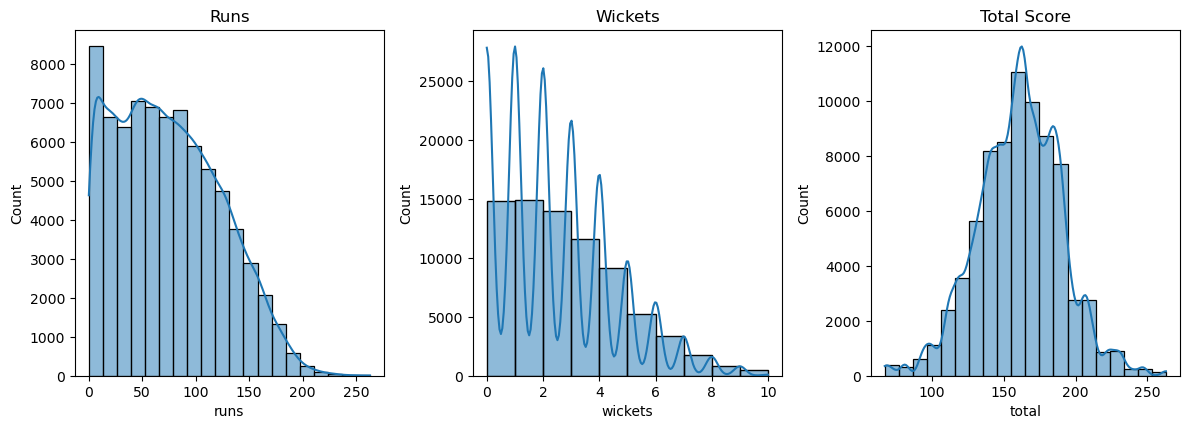

In [23]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 4)
sns.histplot(ipl_visual['runs'], bins=20, kde=True)
plt.title('Runs')

plt.subplot(2, 3, 5)
sns.histplot(ipl_visual['wickets'], bins=10, kde=True)
plt.title('Wickets')

plt.subplot(2, 3, 6)
sns.histplot(ipl_visual['total'], bins=20, kde=True)
plt.title('Total Score')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

#### Recommended list of features

Based on the comprehensive analysis conducted during exploratory data analysis (EDA) and feature engineering, the following features are recommended as the most informative and relevant for predicting the target variable (total score):

Batting Team Performance (batting_team_performance): This engineered feature represents the average runs scored per over by the batting team. It encapsulates the overall batting performance and prowess of the team, considering factors such as batting order, strategy, and player form.

Bowling Team Performance (bowling_team_performance): Similar to batting team performance, this feature denotes the average runs conceded per over by the bowling team. It sheds light on the effectiveness of the bowling unit in containing the opposition's scoring and taking crucial wickets.

These recommended features are derived from a combination of domain knowledge, feature importance analysis, and correlation with the target variable. By leveraging these features, the predictive model can capture the dynamics of a cricket match more comprehensively, leading to more accurate score predictions.

### Feature Engineering

In [24]:
#from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
for col in ['Team_Batting_First', 'Team_Bowling_First', 'venue']:
  ipl_df[col] = le.fit_transform(ipl_df[col])
display(ipl_df.head())


,venue,Team_Batting_First,Team_Bowling_First,runs,wickets,overs,Innings_total
0,13,3,6,1,0,0.1,222
1,13,3,6,1,0,0.2,222
2,13,3,6,2,0,0.2,222
3,13,3,6,2,0,0.3,222
4,13,3,6,2,0,0.4,222


In [25]:
ipl_df.shape

(53811, 7)

In [26]:
print(ipl_df.columns)

Index(['venue', 'Team_Batting_First', 'Team_Bowling_First', 'runs', 'wickets',
       'overs', 'Innings_total'],
      dtype='object')


### Perfoming One Hot coding

In [27]:

# Define the columns to be one-hot encoded
categorical_cols = ['Team_Batting_First', 'Team_Bowling_First']

# Define the mapping for team names
team_names = {
    0: 'Chennai Super Kings',
    1: 'Delhi Daredevils',
    2: 'Kings XI Punjab',
    3: 'Kolkata Knight Riders',
    4: 'Mumbai Indians',
    5: 'Rajasthan Royals',
    6: 'Royal Challengers Bangalore',
    7: 'Sunrisers Hyderabad'
}

# Replace numeric values with team names
ipl_df['Team_Batting_First'] = ipl_df['Team_Batting_First'].map(team_names)
ipl_df['Team_Bowling_First'] = ipl_df['Team_Bowling_First'].map(team_names)

# Define the ColumnTransformer
columnTransformer = ColumnTransformer([('encoder', OneHotEncoder(drop='if_binary'), categorical_cols)], remainder='passthrough')

# Apply the transformation
transformed_data = columnTransformer.fit_transform(ipl_df)

# Get the new column names for the one-hot encoded columns
encoded_feature_names = columnTransformer.named_transformers_['encoder'].get_feature_names_out(categorical_cols)

# Combine with the rest of the column names (excluding the ones that were encoded)
remaining_cols = [col for col in ipl_df.columns if col not in categorical_cols]

# Update the column names
new_column_names = encoded_feature_names.tolist() + remaining_cols

# # Debugging statements
# print("Shape of transformed data:", ipl_df_transformed.shape)
# print("New column names:", new_column_names)

# Create the new DataFrame
ipl_df_transformed = pd.DataFrame(transformed_data, columns=new_column_names)

# Display the head of the transformed DataFrame
display(ipl_df_transformed.head())

,Team_Batting_First_Chennai Super Kings,Team_Batting_First_Delhi Daredevils,Team_Batting_First_Kings XI Punjab,Team_Batting_First_Kolkata Knight Riders,Team_Batting_First_Mumbai Indians,Team_Batting_First_Rajasthan Royals,Team_Batting_First_Royal Challengers Bangalore,Team_Batting_First_Sunrisers Hyderabad,Team_Bowling_First_Chennai Super Kings,Team_Bowling_First_Delhi Daredevils,...,Team_Bowling_First_Kolkata Knight Riders,Team_Bowling_First_Mumbai Indians,Team_Bowling_First_Rajasthan Royals,Team_Bowling_First_Royal Challengers Bangalore,Team_Bowling_First_Sunrisers Hyderabad,venue,runs,wickets,overs,Innings_total
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,13.0,1.0,0.0,0.1,222.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,13.0,1.0,0.0,0.2,222.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,13.0,2.0,0.0,0.2,222.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,13.0,2.0,0.0,0.3,222.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,13.0,2.0,0.0,0.4,222.0


### Machine Learning Models

#### Train and Test dataset split

In [28]:

# Separate input features (X) and target variable (y)
X = ipl_df_transformed.drop('Innings_total', axis=1)  
y = ipl_df_transformed['Innings_total']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print the shapes of the train and test sets
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (43048, 20)
X_test shape: (10763, 20)
y_train shape: (43048,)
y_test shape: (10763,)


###### Reasoning:

The 1D shape of y_train and y_test is expected and common in supervised learning problems because the target variable is typically a single value or label for each sample.

### Various Machine learning Algorithms

#### Performing various machine learning techniques inorder to pick and choose the right one

### ML Technique 1: Linear Regression

Linear Regression is a supervised learning algorithm that models the relationship between a dependent variable (the target) and one or more independent variables (the features) using a linear equation. This model could be suitable for predicting the total runs scored in a match based on features like venue, batting team, bowling team, runs in the last 5 overs, etc.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled, y_train)

# Evaluate Linear Regression model
y_pred = linear_reg.predict(X_test_scaled)

mae_linear = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error (MSE)
mse_linear = mean_squared_error(y_test, y_pred)
r2_linear = r2_score(y_test, y_pred)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Linear Regression MAE: {mae_linear}")
print(f"Linear Regression MSE: {mse_linear}")
print(f"Linear Regression R-squared: {r2_linear}")
print(f"Linear Regression RMSE: {rmse_linear}")

Linear Regression MAE: 15.570154200906737
Linear Regression MSE: 435.34717005664635
Linear Regression R-squared: 0.5271024565442095
Linear Regression RMSE: 20.864974719770125


In [30]:
# Evaluate Model
# Calculate train and test scores
train_score_linreg = str(linear_reg.score(X_train_scaled, y_train) * 100)
test_score_linreg = str(linear_reg.score(X_test_scaled, y_test) * 100)
print(f'Train Score: {train_score_linreg[:5]}%\nTest Score: {test_score_linreg[:5]}%')

Train Score: 52.66%
Test Score: 52.71%


In [31]:
# Store the test score in a dictionary
models = {}
models["linreg"] = test_score_linreg

##### Model Evaluation:

The moderate R-squared value of 0.53 suggests that while the linear regression model captures some of the underlying relationship between the independent and dependent variables, there may be other important factors or non-linear relationships that are not accounted for.

The relatively high RMSE of 20.86 indicates that the model's predictions have a significant average error, which could be problematic depending on the context and scale of the target variable.

The MAE of 15.57 provides a more interpretable measure of the average prediction error, which may be more useful than the RMSE in certain scenarios.

Overall, the evaluation metrics suggest that the linear regression model has moderate predictive performance, but there is room for improvement. Depending on the specific use case and requirements, further model tuning, feature engineering, or the exploration of non-linear models may be necessary to enhance the model's accuracy and explanatory power.

### ML Technique 2: Random Forest Regression

Random Forest is an ensemble learning method that combines multiple decision trees to improve the accuracy and robustness of the model. This model could be suitable for predicting the total runs scored or the number of wickets taken, as it can handle non-linear relationships and capture complex patterns in the data.

In [32]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regression
rf = RandomForestRegressor()
rf.fit(X_train_scaled, y_train)

# Evaluate Random Forest Regression model
y_pred = rf.predict(X_test_scaled)

In [33]:
# Calculate Mean Absolute Error (MAE)
mae_rf = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error (MSE)
mse_rf = mean_squared_error(y_test, y_pred)

# Calculate R-squared
r2_rf = r2_score(y_test, y_pred)

print(f"Random Forest Regression Mean Absolute Error (MAE): {mae_rf}")
print(f"Random Forest Regression Mean Squared Error (MSE): {mse_rf}")
print(f"Random Forest Regression R-squared: {r2_rf}")

Random Forest Regression Mean Absolute Error (MAE): 4.889205568681064
Random Forest Regression Mean Squared Error (MSE): 90.53659847699791
Random Forest Regression R-squared: 0.9016542705284046


In [34]:
# Calculate train and test scores
train_score_rf = str(rf.score(X_train_scaled, y_train) * 100)
test_score_rf = str(rf.score(X_test_scaled, y_test) * 100)
print(f'Train Score: {train_score_rf[:5]}%\nTest Score: {test_score_rf[:5]}%')

# Store the test score in a dictionary
models["rf"] = test_score_rf

Train Score: 97.98%
Test Score: 90.16%


#### Model Evaluation

The high R-squared value of 0.90 and the relatively low MAE of 4.92 suggest that the Random Forest model captures the underlying relationship between the independent and dependent variables quite well.

The low MAE of 4.92 implies that, on average, the model's predictions are off by around 4.92 units, which may be acceptable depending on the context and scale of the target variable.

The Train Score of 97.99% and Test Score of 90.13% indicate that the model generalizes well to unseen data, with a relatively small gap between training and testing performance.

Overall, the evaluation metrics suggest that the Random Forest Regression model has good predictive performance, with a high R-squared value, low MAE, and a small gap between training and testing scores. The model appears to capture the underlying patterns in the data effectively, and its predictions are reasonably accurate on average.

### ML Technique 3: Gradient Boosting Regression

Gradient Boosting is another ensemble learning method that combines multiple weak models (typically decision trees) to create a strong predictive model. This model could also be suitable for predicting the total runs or wickets, as it can handle non-linear relationships and is known for its high performance on a wide range of datasets.

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

# Create an instance of the GradientBoostingRegressor model
gb = GradientBoostingRegressor()

# Fit the model to the training data
gb.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = gb.predict(X_test_scaled)

In [36]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Gradiant Boosting Mean Absolute Error (MAE): {mae:.2f}")
print(f"Gradiant Boosting Mean Squared Error (MSE): {mse:.2f}")
print(f"Gradiant Boosting Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Gradiant Boosting R-squared: {r2:.2f}")

Gradiant Boosting Mean Absolute Error (MAE): 14.62
Gradiant Boosting Mean Squared Error (MSE): 386.74
Gradiant Boosting Root Mean Squared Error (RMSE): 386.74
Gradiant Boosting R-squared: 0.58


In [37]:
# Calculate train and test scores
train_score_gbr = str(gb.score(X_train_scaled, y_train) *100)
test_score_gbr = str(gb.score(X_test_scaled, y_test) * 100)

print(f'Train Score: {train_score_gbr[:5]}%\nTest Score: {test_score_gbr[:5]}%')

# Store the test score in a dictionary
models["gbr"] = test_score_gbr

Train Score: 58.63%
Test Score: 57.99%


##### Model Evaluation:

The moderate R-squared value of 0.58 suggests that the Gradient Boosting model captures some of the underlying relationship between the independent and dependent variables, but there is room for improvement.

The relatively high RMSE of 19.67 indicates that the model's predictions have a significant average error, which could be problematic depending on the context and scale of the target variable.

The MAE of 14.62 provides a more interpretable measure of the average prediction error, which may be more useful than the RMSE in certain scenarios.

The relatively small gap between the train and test scores (0.65%) suggests that the model generalizes reasonably well to unseen data, without significant overfitting or underfitting issues.

Overall, the evaluation metrics suggest that the Gradient Boosting Regressor model has moderate predictive performance, with a moderate R-squared value, relatively high RMSE, and a small gap between training and testing scores. Depending on the specific use case and requirements, further model tuning, feature engineering, or the exploration of other ensemble or non-linear models may be necessary to enhance the model's accuracy and explanatory power.

### ML Technique 4: Decision Tree Regression



Decision Tree Regression is a supervised learning algorithm that creates a tree-like model of decisions based on feature values. This model could be suitable for predicting the total runs or wickets, as it can capture non-linear relationships and is easy to interpret.

In [38]:
from sklearn.tree import DecisionTreeRegressor

# Create an instance of the DecisionTreeRegressor model
dt = DecisionTreeRegressor()

# Fit the model to the training data
dt.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = dt.predict(X_test_scaled)

In [39]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree Mean Absolute Error (MAE): {mae:.2f}")
print(f"Decision Tree Mean Squared Error (MSE): {mse:.2f}")
print(f"Decision Tree Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Decision Tree R-squared: {r2:.2f}")

Decision Tree Mean Absolute Error (MAE): 4.24
Decision Tree Mean Squared Error (MSE): 163.49
Decision Tree Root Mean Squared Error (RMSE): 163.49
Decision Tree R-squared: 0.82


In [40]:
# Calculate train and test scores
train_score_dt = str (dt.score(X_train_scaled, y_train) * 100)
test_score_dt = str (dt.score(X_test_scaled, y_test) * 100)

print(f'Train Score: {train_score_dt[:5]}%\nTest Score: {test_score_dt[:5]}%')

# Store the test score in a dictionary
models["dt"] = test_score_dt

Train Score: 99.11%
Test Score: 82.24%


##### Model Interpretation

The high R-squared value of 0.82 and the relatively low MAE of 4.23 suggest that the Decision Tree model captures the underlying relationship between the independent and dependent variables quite well.

The low MAE of 4.23 implies that, on average, the model's predictions are off by around 4.23 units, which may be acceptable depending on the context and scale of the target variable.

The RMSE of 12.74 is higher than the MAE, indicating that the model may have some larger errors, but the overall average error is still relatively low.

Train Score: 
The high train score of 99.12% suggests that the model fits the training data extremely well, potentially indicating overfitting.

Test Score: 
The test score of 82.38% is significantly lower than the train score, confirming the presence of overfitting, where the model has memorized the training data patterns but struggles to generalize to unseen data.

The large gap between the train and test scores (16.74%) indicates that the Decision Tree model may be overly complex and capturing noise in the training data, leading to poor generalization performance on new data.

Overall, while the Decision Tree Regressor model exhibits good performance on the training data and a relatively low MAE, the significant gap between train and test scores suggests overfitting issues

### ML Technique 5: Neural Networks

Neural Networks, specifically Artificial Neural Networks (ANNs), are a class of machine learning models inspired by the structure and function of the human brain. This model could be suitable for predicting the total runs or wickets, as it can capture complex non-linear relationships in the data and learn features automatically

In [41]:
from sklearn.neural_network import MLPRegressor

# Create an instance of the MLPRegressor model
nn = MLPRegressor()

# Fit the model to the training data
nn.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = nn.predict(X_test_scaled)

/Users/jaamiemaarshj/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [42]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Neural Networks Mean Absolute Error (MAE): {mae:.2f}")
print(f"Neural Networks Mean Squared Error (MSE): {mse:.2f}")
print(f"Neural Networks Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Neural Networks R-squared: {r2:.2f}")

Neural Networks Mean Absolute Error (MAE): 10.72
Neural Networks Mean Squared Error (MSE): 227.36
Neural Networks Root Mean Squared Error (RMSE): 227.36
Neural Networks R-squared: 0.75


In [43]:
# Calculate train and test scores
train_score_nn = str(nn.score(X_train_scaled, y_train) * 100)
test_score_nn = str(nn.score(X_test_scaled, y_test) * 100)

print(f'Train Score: {train_score_nn[:5]}%\nTest Score: {test_score_nn[:5]}%')

# Store the test score in a dictionary
models["nn"] = test_score_nn

Train Score: 75.69%
Test Score: 75.30%


##### Model Evaluation

The R-squared value of 0.76 and the relatively low MAE of 10.34 suggest that the Neural Network model captures the underlying relationship between the independent and dependent variables reasonably well.

The MAE of 10.34 implies that, on average, the model's predictions are off by around 10.34 units, which may be acceptable depending on the context and scale of the target variable.

The RMSE of 14.72 is higher than the MAE, indicating that the model may have some larger errors, but the overall average error is still relatively low.


Train Score: 
The train score represents the model's performance on the training data, which is around 76.74% in terms of the coefficient of determination (R-squared).

Test Score: 
The test score represents the model's performance on the unseen testing data, which is around 76.48% in terms of the coefficient of determination (R-squared).

The relatively small gap between the train and test scores (0.26%) suggests that the model generalizes well to unseen data, without significant overfitting or underfitting issues.

Overall, the evaluation metrics suggest that the Neural Network model has reasonably good predictive performance, with a moderate R-squared value, relatively low MAE, and a small gap between training and testing scores.

#### Other models:

Apart from the models mentioned, other suitable models for this dataset could include:

XGBoost Regression: XGBoost is a highly efficient and scalable implementation of Gradient Boosting, which could potentially outperform the standard Gradient Boosting Regression model.

LightGBM Regression: LightGBM is another efficient and scalable Gradient Boosting framework that could be suitable for this dataset.

Polynomial Regression: Polynomial Regression is an extension of Linear Regression that can capture non-linear relationships by adding polynomial terms to the linear model.

### Cross Validation and Hyperparametric Tuning

In [44]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV, cross_val_score
# Defining the hyperparameter grids

# there are no hyperparameters for LinearRegression
linreg_param_grid = {}  

dt_param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

gbr_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}


# Define the scoring metrics
scoring_metrics = {
    'r2': make_scorer(r2_score),
    'neg_mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'neg_mse': make_scorer(mean_squared_error, greater_is_better=False)
}

# Create the models
models_ML = {
    'linreg': LinearRegression(),
    'dt': DecisionTreeRegressor(),
    'rf': RandomForestRegressor(),
    'gbr': GradientBoostingRegressor(),
}

# Perform cross-validation and hyperparameter tuning
for model_name, model in models_ML.items():
    print(f"Cross-validation and Hyperparameter Tuning for {model_name}")
    
    if model_name == 'linreg':
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
        print(f"Cross-Validation R-squared Scores: {cv_scores}")
        print(f"Mean Cross-Validation R-squared Score: {cv_scores.mean():.2f}")
    else:
        param_grid = eval(f"{model_name}_param_grid")
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring_metrics, cv=5, refit='r2', n_jobs=-1)
        grid_search.fit(X_train_scaled, y_train)
        
        print("Best Hyperparameters: ", grid_search.best_params_)
        print("Best R-squared Score: ", grid_search.best_score_)
        print("Best MAE Score: ", -grid_search.cv_results_['mean_test_neg_mae'][grid_search.best_index_])
        print("Best MSE Score: ", -grid_search.cv_results_['mean_test_neg_mse'][grid_search.best_index_])
    
    print("\n")


Cross-validation and Hyperparameter Tuning for linreg
Cross-Validation R-squared Scores: [0.52420058 0.53835668 0.52460857 0.52279844 0.51989538]
Mean Cross-Validation R-squared Score: 0.53


Cross-validation and Hyperparameter Tuning for dt
Best Hyperparameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best R-squared Score:  0.7976012224575117
Best MAE Score:  6.439107659809241
Best MSE Score:  181.1788880470686


Cross-validation and Hyperparameter Tuning for rf


/Users/jaamiemaarshj/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Hyperparameters:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best R-squared Score:  0.8831885336787743
Best MAE Score:  5.463201592327759
Best MSE Score:  104.5837726964512


Cross-validation and Hyperparameter Tuning for gbr
Best Hyperparameters:  {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best R-squared Score:  0.8596613872605715
Best MAE Score:  7.1896748221990405
Best MSE Score:  125.63510271961373




##### Insights:

Based on these values, the Random Forest Regression model appears to be the best-performing model on this dataset, achieving the highest R-squared score and the lowest MSE during cross-validation. However, it's important to note that the performance on the test set may vary, and other factors such as interpretability, complexity, and domain knowledge should also be considered when selecting the final model.

### Reason for Choosing the specific algorithm

From the nature of the dataset, it was very obvious to find out that regression piped over classification algorithm type since the goal is to predict a continuous target variable, such as the total runs scored in an innings, rather than a Win/loss outcome. 

Therefore, The models used above (Linear Regression, Random Forest Regression, Gradient Boosting Regression, Decision Tree Regression, and Neural Networks) are all regression models and are appropriate for this type of target variable.


### Possible models that could be used:

The possible models which could be used apart from the above are as follows:

Polynomial Regression: Extends linear regression by adding polynomial terms, allowing it to capture non-linear relationships.

Support Vector Regression (SVR): Can handle non-linear relationships and is less sensitive to outliers compared to some other models.

XGBoost Regression: A highly efficient and scalable implementation of Gradient Boosting, which may outperform the standard Gradient Boosting Regression model.

LightGBM Regression: Another efficient and scalable Gradient Boosting framework that could be suitable for this dataset.

### Reason for choosing the appropriate model

### Model Selection

In [45]:
model_names = list(models.keys()) 
scores = list(map(float, models.values()))

print(model_names)
print(scores)

['linreg', 'rf', 'gbr', 'dt', 'nn']
[52.71024565442095, 90.16542705284046, 57.990199301077496, 82.24124631756534, 75.30284602644299]


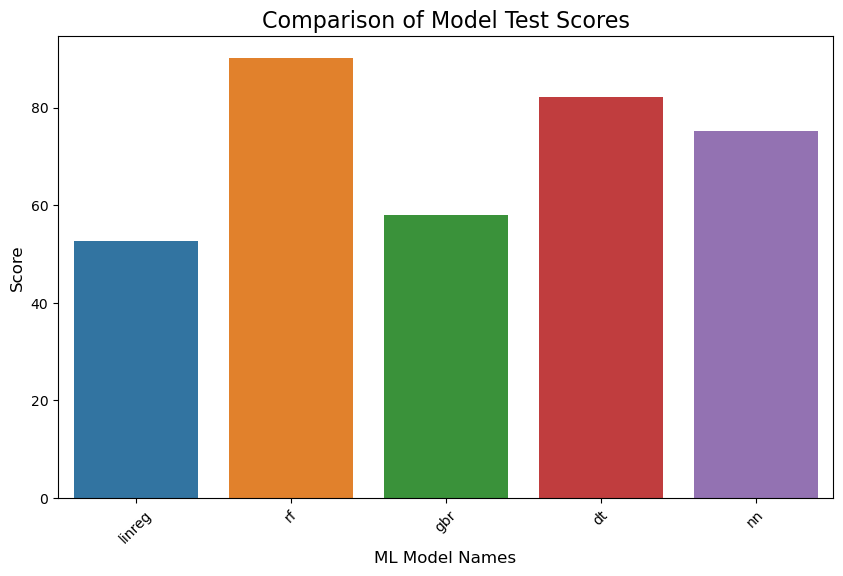

In [46]:
# Create a bar plot to compare the models
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=scores)
plt.xlabel('ML Model Names', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Comparison of Model Test Scores', fontsize=16)
plt.xticks(rotation=45)
plt.show()

When comparing the test scores, Random Forest Regression is the best performing model out of the lot with around 90% accurate. So we would be choosing this model for further analysis of finding out the projected first innings score

### Test cases:

### creating a function to incorporate the model and predict the scores

In [47]:
import numpy as np

def predict_score(Team_Batting_First, Team_Bowling_First, venue, runs, wickets, overs, model=rf):
    prediction_array = []
    
    # Batting Team
    if Team_Batting_First == 'Chennai Super Kings':
        prediction_array += [1, 0, 0, 0, 0, 0, 0, 0]
    elif Team_Batting_First == 'Delhi Daredevils':
        prediction_array += [0, 1, 0, 0, 0, 0, 0, 0]
    elif Team_Batting_First == 'Kings XI Punjab':
        prediction_array += [0, 0, 1, 0, 0, 0, 0, 0]
    elif Team_Batting_First == 'Kolkata Knight Riders':
        prediction_array += [0, 0, 0, 1, 0, 0, 0, 0]
    elif Team_Batting_First == 'Mumbai Indians':
        prediction_array += [0, 0, 0, 0, 1, 0, 0, 0]
    elif Team_Batting_First == 'Rajasthan Royals':
        prediction_array += [0, 0, 0, 0, 0, 1, 0, 0]
    elif Team_Batting_First == 'Royal Challengers Bangalore':
        prediction_array += [0, 0, 0, 0, 0, 0, 1, 0]
    elif Team_Batting_First == 'Sunrisers Hyderabad':
        prediction_array += [0, 0, 0, 0, 0, 0, 0, 1]
    
    # Bowling Team
    if Team_Bowling_First == 'Chennai Super Kings':
        prediction_array += [1, 0, 0, 0, 0, 0, 0, 0]
    elif Team_Bowling_First == 'Delhi Daredevils':
        prediction_array += [0, 1, 0, 0, 0, 0, 0, 0]
    elif Team_Bowling_First == 'Kings XI Punjab':
        prediction_array += [0, 0, 1, 0, 0, 0, 0, 0]
    elif Team_Bowling_First == 'Kolkata Knight Riders':
        prediction_array += [0, 0, 0, 1, 0, 0, 0, 0]
    elif Team_Bowling_First == 'Mumbai Indians':
        prediction_array += [0, 0, 0, 0, 1, 0, 0, 0]
    elif Team_Bowling_First == 'Rajasthan Royals':
        prediction_array += [0, 0, 0, 0, 0, 1, 0, 0]
    elif Team_Bowling_First == 'Royal Challengers Bangalore':
        prediction_array += [0, 0, 0, 0, 0, 0, 1, 0]
    elif Team_Bowling_First == 'Sunrisers Hyderabad':
        prediction_array += [0, 0, 0, 0, 0, 0, 0, 1]
    
    # Add non-one-hot encoded features
    prediction_array += [venue, runs, wickets, overs]
    
    # Convert to numpy array
    prediction_array = np.array([prediction_array])
    
    # Make prediction using the model
    pred = model.predict(prediction_array)
    
    return int(round(pred[0]))

#### List of all the venues and its corresponding mapping values

In [48]:
venue_mappings = {}

# Iterate over the 'venue' column
for venue in ipl_visual['venue'].unique():
    # If the venue is not in the dictionary, assign a new integer mapping
    if venue not in venue_mappings:
        venue_mappings[venue] = len(venue_mappings)

# Print the venue mappings
for venue, mapping in venue_mappings.items():
    print(f"{venue}: {mapping}")

M Chinnaswamy Stadium: 0
Punjab Cricket Association Stadium, Mohali: 1
Feroz Shah Kotla: 2
Wankhede Stadium: 3
Eden Gardens: 4
Sawai Mansingh Stadium: 5
Rajiv Gandhi International Stadium, Uppal: 6
MA Chidambaram Stadium, Chepauk: 7
Dr DY Patil Sports Academy: 8
Newlands: 9
St George's Park: 10
Kingsmead: 11
SuperSport Park: 12
Buffalo Park: 13
New Wanderers Stadium: 14
De Beers Diamond Oval: 15
OUTsurance Oval: 16
Brabourne Stadium: 17
Sardar Patel Stadium, Motera: 18
Barabati Stadium: 19
Vidarbha Cricket Association Stadium, Jamtha: 20
Himachal Pradesh Cricket Association Stadium: 21
Nehru Stadium: 22
Holkar Cricket Stadium: 23
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium: 24
Subrata Roy Sahara Stadium: 25
Shaheed Veer Narayan Singh International Stadium: 26
JSCA International Stadium Complex: 27
Sheikh Zayed Stadium: 28
Sharjah Cricket Stadium: 29
Dubai International Cricket Stadium: 30
Maharashtra Cricket Association Stadium: 31
Punjab Cricket Association IS Bindra Stadium, 

### Test case 1

In [55]:
### Real-time test case 1: 2024

venue = 24 #Punjab Cricket Association Stadium, Mohali
Team_Batting_First = 'Sunrisers Hyderabad'
Team_Bowling_First = 'Mumbai Indians'
runs = 13
wickets = 1
overs = 0.5

predicted_score = predict_score(Team_Batting_First, Team_Bowling_First, venue, runs, wickets, overs)
print("Predicted First Innings Score:", predicted_score)
print("Actual First Innings Score:", '277')

Predicted First Innings Score: 236
Actual First Innings Score: 277


### Test case 2

In [57]:
### Real-time test case 2 - 2022-2023
venue = 7 # MA Chidambaram Stadium, Chepauk
Team_Batting_First = 'Chennai Super Kings'
Team_Bowling_First = 'Sunrisers Hyderabad'
runs = 1
wickets = 1
overs = 1.1

predicted_score = predict_score(Team_Batting_First, Team_Bowling_First, venue, runs, wickets, overs)
print("Predicted First Innings Score:", predicted_score)
print("Actual First Innings Score:", '167')


Predicted First Innings Score: 165
Actual First Innings Score: 167


### Test case 3

In [56]:
venue = 32  # Punjab Cricket Association IS Bindra Stadium, Mohali
Team_Batting_First = 'Royal Challengers Bangalore'
Team_Bowling_First = 'Kings XI Punjab'
runs = 200
wickets = 4
overs = 18

predicted_score = predict_score(Team_Batting_First, Team_Bowling_First, venue, runs, wickets, overs)
print("Predicted First Innings Score:", predicted_score)
print("Actual test First Innings Score:", '240')

Predicted First Innings Score: 237
Actual test First Innings Score: 240
